In [1]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [2]:
REQ_DATA = 't_1.00_U_0.10_Vpp_0.800'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if "chimax_400" in f]


In [3]:
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df


,psi,dV,mean_Sz,mean_fill,model_params
1,"MPS, L=2, bc='infinite'.\nchi: [400, 400]\nsit...",2.00,-1.069283e-05,0.537383,"{'L': 2, 'U': 0.1, 'Vpm': 2.8, 'Vpp': 0.8, 'bc..."
5,"MPS, L=2, bc='infinite'.\nchi: [400, 400]\nsit...",2.60,4.284176e-11,0.494853,"{'L': 2, 'U': 0.1, 'Vpm': 3.4000000000000004, ..."
3,"MPS, L=2, bc='infinite'.\nchi: [400, 400]\nsit...",3.00,2.222244e-05,0.468036,"{'L': 2, 'U': 0.1, 'Vpm': 3.8, 'Vpp': 0.8, 'bc..."
4,"MPS, L=2, bc='infinite'.\nchi: [400, 400]\nsit...",3.05,-1.114617e-06,0.464498,"{'L': 2, 'U': 0.1, 'Vpm': 3.8499999999999996, ..."
2,"MPS, L=2, bc='infinite'.\nchi: [400, 400]\nsit...",3.15,2.405653e-02,1.941774,"{'L': 2, 'U': 0.1, 'Vpm': 3.95, 'Vpp': 0.8, 'b..."
0,"MPS, L=2, bc='infinite'.\nchi: [400, 400]\nsit...",3.40,-1.835605e-01,0.399731,"{'L': 2, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc..."


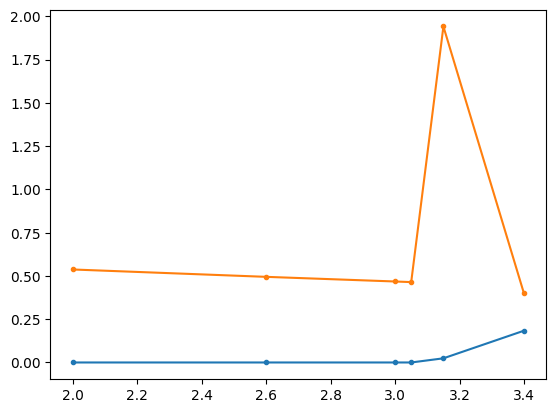

In [4]:
fig, ax = plt.subplots(1)
ax.plot(df['dV'], np.abs(df['mean_Sz']), '.-', c='C0')
ax.plot(df['dV'], np.abs(df['mean_fill']), '.-', c='C1')

/tmp/ipykernel_1833578/1368748437.py:4: RuntimeWarning: divide by zero encountered in power
  plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")


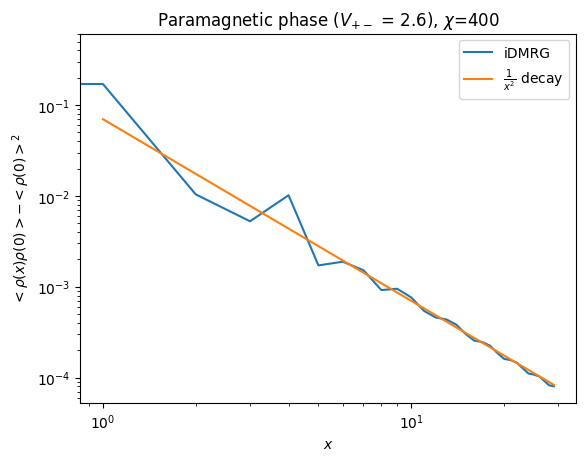

In [32]:
psipm = df[np.isclose(df['dV'], 2.60)]['psi'].iloc[0]
distrange = 30
plt.plot(observables.charge_corr(psipm, length=distrange, connected=True), label="iDMRG")
plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")
plt.yscale('log')
plt.xscale('log')
plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
plt.ylabel(r"$<\rho(x) \rho(0)> - <\rho(0)>^2$")
plt.xlabel(r"$x$")
plt.yscale('log')
plt.xscale('log')
plt.legend()

/tmp/ipykernel_1833578/717278757.py:3: RuntimeWarning: divide by zero encountered in power
  plt.plot(0.06 * (np.arange(distrange,dtype=float)[0:])**-2, label=r"$\frac{1}{x^2}$ decay")


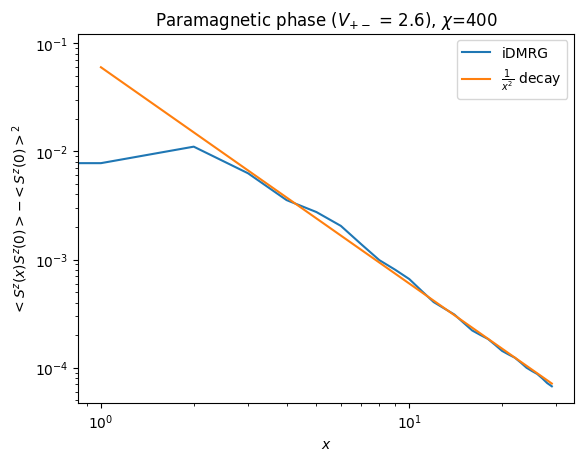

In [24]:
distrange = 30
plt.plot(observables.SzSz_corr(psipm, length=distrange, connected=True), label="iDMRG")
plt.plot(0.06 * (np.arange(distrange,dtype=float)[0:])**-2, label=r"$\frac{1}{x^2}$ decay")
plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
plt.ylabel(r"$<S^z(x) S^z(0)> - <S^z(0)>^2$")
plt.xlabel(r"$x$")
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [25]:
psifm = df[np.isclose(df['dV'], 3.4)]['psi'].iloc[0]
distrange = 30
fmspincorr = observables.SzSz_corr(psifm, length=distrange, connected=True)
fmchargecorr = observables.charge_corr(psifm, length=distrange, connected=True)

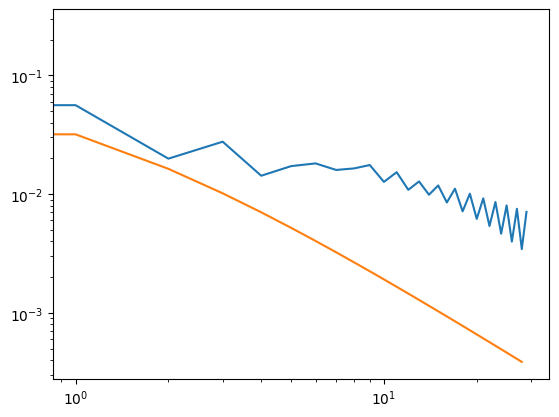

In [26]:
plt.plot(fmchargecorr)
plt.plot(0.1 * (np.arange(distrange, dtype=float)[1:]**(-1.65)))
plt.yscale('log')
plt.xscale('log')

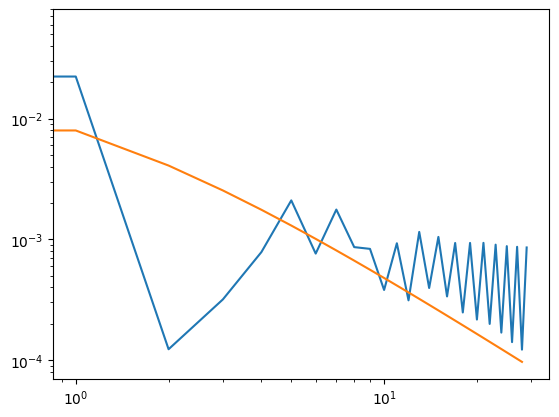

In [ ]:
distrange = 30
plt.plot(fmspincorr)
# plt.plot(0.025 * (np.arange(distrange)[1:])**-1.65)
plt.yscale('log')
plt.xscale('log')

In [ ]:
ser_psi = df[np.isclose(df['dV'], 2.9)]
psitest  = ser_psi['psi'].iloc[0]
test_model_params = ser_psi['model_params'].iloc[0]
parat, paraU, paraVpp, paraVpm = test_model_params['t'], test_model_params['U'], test_model_params['Vpp'], test_model_params['Vpm']
compute_Luttinger_parameter(parat, paraU, paraVpp, paraVpm)

((0.6390970286164492+0j), (4.049351809334104+0j))

In [ ]:
psifm.correlation_length2(), psipm.correlation_length2()

(np.float64(344.82118938891966), np.float64(36.18109209143194))

In [ ]:
longdistcorrfmspin = observables.SzSz_corr(psifm, length=1000, connected=True) #correlation length is 344


KeyboardInterrupt: 

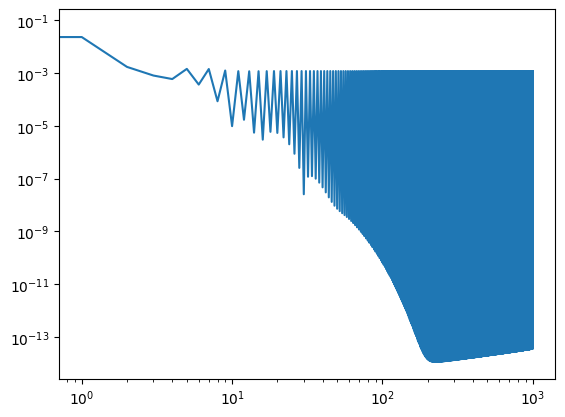

In [ ]:
plt.loglog(longdistcorrfmspin)